Mulyiple Linear Regression on two columns



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('placement.csv')

In [ ]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [ ]:
X = df.iloc[:,0]
y = df.iloc[:,1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#converting Series into 1D array using "values" then converting futher into 2Darray using reshape
X_train = X_train.values.reshape(-1,1)
X_test = X_test.values.reshape(-1,1)
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [ ]:
class MLR():
  def __init__(self):
        self.coef_ = None
        self.intercept_ = None

  def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)

        #calculate betas
        betas = np.linalg.inv(np.dot(X_train.T, X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

  def predict(self, X_test):
        y_pred = np.dot(X_test, self.coef_) + self.intercept_
        return y_pred

In [ ]:
mlr = MLR()

In [ ]:
mlr.fit(X_train, y_train)

In [ ]:
y_pred = mlr.predict(X_test)

In [ ]:
r2_score(y_test, y_pred)

0.7730984312051704

In [ ]:
mlr.coef_

array([[0.57425647]])

In [ ]:
mlr.intercept_

array([-1.02700694])

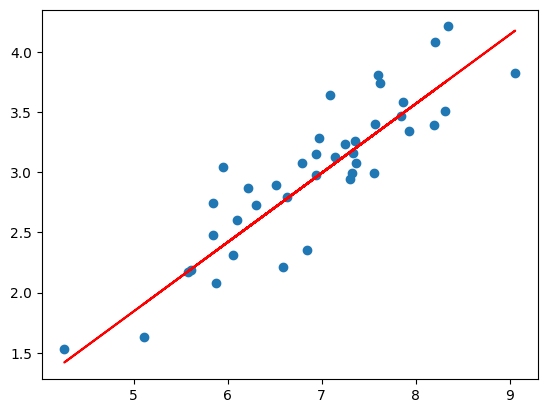

In [ ]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred,color='red')
plt.show()